# 1.0 Customer Data Cleaning & Frequency Analysis

- Objective:
    - Clean and standardize the Pizza House customer list exported from Clover POS
    - Remove invalid and unusable customer records
    - Prepare a clean customer-level dataset for downstream frequency analysis

- Key Goals:
    - Audit customer data quality
    - Identify null-heavy fields and duplicate customer records
    - Standardize customer identifiers for cleaner analysis
    - Build a foundation for repeat customer analysis

- Business Value:
    - Improves customer list usability for future marketing
    - Helps identify repeat-customer opportunities
    - Supports retention and loyalty strategy development

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# load customer dataset
df_customers = pd.read_csv("../data/raw/customers_raw.csv")

# preview
df_customers.head()

,Customer ID,First Name,Last Name,Phone Number,Email Address,Address Line 1,Address Line 2,Address Line 3,City,State / Province,Postal / Zip Code,Country,Customer Since,Marketing Allowed,Additional Addresses
0,354P0KD4FANC8,MANUALLY,ENTERED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31-Jan-2026 03:22 PM PST,No,NaN
1,PJ61J5TK1Z6V0,NaN,NaN,9162129352,NaN,6710 37 Ave,NaN,NaN,NaN,NaN,NaN,NaN,31-Jan-2026 03:18 PM PST,No,NaN
2,58XGSAMG3ENAT,Jemel togo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31-Jan-2026 03:13 PM PST,No,NaN
3,NK1G73MBSXP56,Togo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31-Jan-2026 03:03 PM PST,No,NaN
4,0TV5NWM71NPTJ,Togo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31-Jan-2026 03:03 PM PST,No,NaN


## 1.1 Initial Customer Data Audit

- Purpose:
    - Understand the size, structure, and quality of the raw customer dataset
    - Identify missing values, duplicate records, and key fields available for cleaning

- Focus Areas:
    - Row and column count
    - Column names
    - Missing values
    - Exact duplicate rows

In [75]:
# dataset shape
df_customers.shape

(47551, 15)

In [76]:
# column list
df_customers.columns.tolist()

['Customer ID',
 'First Name',
 'Last Name',
 'Phone Number',
 'Email Address',
 'Address Line 1',
 'Address Line 2',
 'Address Line 3',
 'City',
 'State / Province',
 'Postal / Zip Code',
 'Country',
 'Customer Since',
 'Marketing Allowed',
 'Additional Addresses']

In [77]:
# missing values by column
df_customers.isna().sum().sort_values(ascending=False)

Additional Addresses    47548
Country                 47542
Address Line 3          47541
City                    47539
State / Province        47539
Postal / Zip Code       47532
Address Line 2          47438
Email Address           47392
Address Line 1          34874
Last Name               32374
Phone Number            16220
First Name               4440
Customer ID                 0
Customer Since              0
Marketing Allowed           0
dtype: int64

In [78]:
# exact duplicate rows
df_customers.duplicated().sum()

0

## 1.2 Initial Audit Findings

- Key Findings:
    - The customer dataset has no exact duplicate rows at the full-row level
    - Email Address is missing for the vast majority of records, so email is not a reliable identifier
    - Phone Number is missing in a meaningful share of records, but it is still the strongest practical identifier available
    - Address-related columns are mostly null and do not provide much value for this analysis
    - Customer ID and Customer Since are fully populated and may help preserve record structure during cleaning

- Interpretation:
    - This customer file appears to function more like a partially captured POS contact table than a complete CRM database
    - Customer matching will likely depend on phone number first, with customer name used only as a supporting field
    - Records with no phone number and no usable name information will have limited analytical value

- Cleaning Direction:
    - Remove low-value records with no practical identifier
    - Standardize customer names
    - Normalize phone numbers
    - Preserve Customer ID and Customer Since for traceability

# 2.0 Customer Data Cleaning Plan

- Objective:
    - Build a cleaner, more usable customer table for frequency analysis and future customer strategy work

- Cleaning Priorities:
    - Remove records with no usable customer identifier
    - Standardize customer name formatting
    - Normalize phone number formatting
    - Preserve key business fields needed for downstream analysis

- Identifier Strategy:
    - Primary identifier:
        - Phone Number
    - Secondary support fields:
        - First Name
        - Last Name
        - Customer ID

In [79]:
# create a working copy
customers = df_customers.copy()

# keep only columns relevant to this workbook
customers = customers[
    [
        'Customer ID',
        'First Name',
        'Last Name',
        'Phone Number',
        'Email Address',
        'Customer Since',
        'Marketing Allowed',
        'Address Line 1'
    ]
].copy()

# clean address field
customers['Address Line 1'] = customers['Address Line 1'].replace('', pd.NA)

customers.head()

,Customer ID,First Name,Last Name,Phone Number,Email Address,Customer Since,Marketing Allowed,Address Line 1
0,354P0KD4FANC8,MANUALLY,ENTERED,NaN,NaN,31-Jan-2026 03:22 PM PST,No,NaN
1,PJ61J5TK1Z6V0,NaN,NaN,9162129352,NaN,31-Jan-2026 03:18 PM PST,No,6710 37 Ave
2,58XGSAMG3ENAT,Jemel togo,NaN,NaN,NaN,31-Jan-2026 03:13 PM PST,No,NaN
3,NK1G73MBSXP56,Togo,NaN,NaN,NaN,31-Jan-2026 03:03 PM PST,No,NaN
4,0TV5NWM71NPTJ,Togo,NaN,NaN,NaN,31-Jan-2026 03:03 PM PST,No,NaN


In [80]:
# preview missing values in the reduced working table
customers.isna().sum().sort_values(ascending=False)

Email Address        47392
Address Line 1       34874
Last Name            32374
Phone Number         16220
First Name            4440
Customer ID              0
Customer Since           0
Marketing Allowed        0
dtype: int64

## 2.1 Remove Unusable Customer Records

- Objective:
    - Remove records that cannot be used for customer identification or analysis

- Removal Criteria:
    - Missing Phone Number AND missing First Name
    - These records cannot be reliably tied to a real customer

- Reasoning:
    - Phone Number is the primary identifier
    - First Name provides minimal fallback context
    - Records missing both have no analytical value

- Expected Outcome:
    - Reduction in dataset size
    - Increase in data quality for downstream analysis

In [81]:
# before cleaning
initial_count = len(customers)

# remove rows with no phone AND no first name
customers = customers[
    ~(customers['Phone Number'].isna() & customers['First Name'].isna())
]

# after cleaning
final_count = len(customers)

# impact
removed_rows = initial_count - final_count

initial_count, final_count, removed_rows

(47551, 46668, 883)

In [82]:
# confirm removal worked
customers[
    customers['Phone Number'].isna() & customers['First Name'].isna()
]

,Customer ID,First Name,Last Name,Phone Number,Email Address,Customer Since,Marketing Allowed,Address Line 1


## 2.2 Standardize Customer Fields

- Objective:
    - Normalize customer names and phone numbers for consistency and matching

- Standardization Steps:
    - Clean First Name and Last Name:
        - Remove leading/trailing whitespace
        - Convert to proper case (e.g., "JEMEL" → "Jemel")
    - Normalize Phone Number:
        - Remove all non-numeric characters
        - Ensure consistent formatting for matching

- Reasoning:
    - Standardized fields improve:
        - Deduplication accuracy
        - Join success with order data
        - Overall dataset readability

- Expected Outcome:
    - Clean, consistent customer identifiers ready for deduplication

In [83]:
# clean first name
customers['First Name'] = (
    customers['First Name']
    .astype(str)
    .str.strip()
    .str.title()
)

# clean last name
customers['Last Name'] = (
    customers['Last Name']
    .astype(str)
    .str.strip()
    .str.title()
)

In [84]:
# normalize phone numbers (remove all non-digits)
customers['Phone Number'] = (
    customers['Phone Number']
    .astype(str)
    .str.replace(r'\D', '', regex=True)
)

In [85]:
# preview cleaned fields
customers[['First Name', 'Last Name', 'Phone Number']].head(10)

,First Name,Last Name,Phone Number
0,Manually,Entered,
1,Nan,Nan,9162129352
2,Jemel Togo,Nan,
3,Togo,Nan,
4,Togo,Nan,
5,Maria,Nan,9168890517
6,Alex,Nan,2797864367
7,Cereena,Nan,9162301496
8,"""Flores,Adam""",Nan,9163292467
9,Togo,Nan,


In [86]:
# replace empty or invalid phone values with NaN
customers['Phone Number'] = customers['Phone Number'].replace('', pd.NA)
customers['Phone Number'] = customers['Phone Number'].replace('nan', pd.NA)

In [87]:
# preview cleaned fields
customers[['First Name', 'Last Name', 'Phone Number']].head(10)

,First Name,Last Name,Phone Number
0,Manually,Entered,<NA>
1,Nan,Nan,9162129352
2,Jemel Togo,Nan,<NA>
3,Togo,Nan,<NA>
4,Togo,Nan,<NA>
5,Maria,Nan,9168890517
6,Alex,Nan,2797864367
7,Cereena,Nan,9162301496
8,"""Flores,Adam""",Nan,9163292467
9,Togo,Nan,<NA>


## 2.3 Deduplicate Customers

- Objective:
    - Collapse multiple records into unique customers

- Strategy:
    - Use Phone Number as the primary identifier
    - Each unique phone number represents one customer

- Handling Missing Phone Numbers:
    - Customers without phone numbers cannot be reliably deduplicated
    - These will be excluded from the deduplicated dataset

- Expected Outcome:
    - Significant reduction in total customer count
    - Creation of a true “unique customer” dataset

In [88]:
# keep only rows with valid phone numbers
customers_with_phone = customers[customers['Phone Number'].notna()].copy()

customers_with_phone.shape

(31331, 8)

In [89]:
# deduplicate by phone number
customers_dedup = customers_with_phone.drop_duplicates(
    subset=['Phone Number'],
    keep='first'
)

customers_dedup.shape

(24146, 8)

In [90]:
# compare counts
total_rows = len(customers)
with_phone = len(customers_with_phone)
deduped = len(customers_dedup)

total_rows, with_phone, deduped

(46668, 31331, 24146)

## 2.4 Construct Clean Customer Dataset

- Objective:
    - Create a clean, deduplicated customer table for downstream analysis

- Dataset Characteristics:
    - One row per unique customer
    - Identified by Phone Number
    - Includes standardized names and key metadata

- Key Fields:
    - Customer ID (original)
    - Clean customer_id (new)
    - First Name / Last Name
    - Phone Number
    - Email Address
    - Address Line 1
    - Customer Since

- Output:
    - customers_final becomes the working dataset for all customer-level analysis

In [91]:
# create final customer dataset
customers_final = customers_dedup.copy()

# reset index
customers_final = customers_final.reset_index(drop=True)

# create new clean customer id
customers_final['customer_id_clean'] = customers_final.index + 1

customers_final.head()

,Customer ID,First Name,Last Name,Phone Number,Email Address,Customer Since,Marketing Allowed,Address Line 1,customer_id_clean
0,PJ61J5TK1Z6V0,Nan,Nan,9162129352,NaN,31-Jan-2026 03:18 PM PST,No,6710 37 Ave,1
1,V9B7S61M0QNFJ,Maria,Nan,9168890517,NaN,31-Jan-2026 02:45 PM PST,No,NaN,2
2,DS58XDVBBF4R2,Alex,Nan,2797864367,NaN,31-Jan-2026 02:33 PM PST,No,NaN,3
3,F4EFFYPKBF80R,Cereena,Nan,9162301496,NaN,31-Jan-2026 02:12 PM PST,No,6425 Somis Way,4
4,ZDAFYPMR1CSQA,"""Flores,Adam""",Nan,9163292467,NaN,31-Jan-2026 01:45 PM PST,No,6100 48th Ave #2202,5


In [92]:
# combine first and last name
customers_final['full_name'] = (
    customers_final['First Name'].fillna('') + ' ' +
    customers_final['Last Name'].fillna('')
).str.strip()

In [93]:
# reorder columns for readability
customers_final = customers_final[
    [
        'customer_id_clean',
        'Customer ID',
        'full_name',
        'First Name',
        'Last Name',
        'Phone Number',
        'Email Address',
        'Address Line 1',
        'Customer Since',
        'Marketing Allowed'
    ]
]

In [94]:
customers_final.to_csv("../data/cleaned/customers_clean.csv", index=False)

# 3.0 Customer Analysis Scope Reset

- Objective:
    - Reassess the scope of customer frequency analysis based on available data

- Key Finding:
    - The orders dataset does not contain a consistent customer identifier (e.g., Phone Number or Customer ID)

- Implication:
    - Orders cannot be directly linked to individual customers
    - True customer frequency (orders per customer) cannot be calculated from available data

- Analytical Pivot:
    - Proceed with customer-level analysis using the cleaned customer dataset
    - Identify insights that can still be derived from customer records alone
    - Document the limitation as a POS data architecture gap

- Business Value:
    - Highlights a critical limitation in the current system
    - Establishes opportunity for improved data capture and customer analytics

## 3.1 Customer Dataset Overview

- Objective:
    - Understand the size and structure of the cleaned customer dataset

- Key Metrics:
    - Total number of unique customers
    - Availability of contact information (phone, email)
    - Marketing eligibility

- Business Value:
    - Provides a baseline view of the customer base
    - Helps assess how actionable the dataset is for outreach and retention

In [95]:
# total customers
total_customers = len(customers_final)

# customers with phone
customers_with_phone = customers_final['Phone Number'].notna().sum()

# customers with email
customers_with_email = customers_final['Email Address'].notna().sum()

# marketing allowed (cleaned)
customers_final['Marketing Allowed Flag'] = customers_final['Marketing Allowed'].map({
    'Yes': 1,
    'No': 0
})

marketing_allowed = customers_final['Marketing Allowed Flag'].sum()

print("Customer Dataset Overview")
print("-" * 30)
print(f"Total Customers        : {total_customers}")
print(f"Customers w/ Phone     : {customers_with_phone}")
print(f"Customers w/ Email     : {customers_with_email}")
print(f"Marketing Consent      : {marketing_allowed}")

Customer Dataset Overview
------------------------------
Total Customers        : 24146
Customers w/ Phone     : 24146
Customers w/ Email     : 100
Marketing Consent      : 595


## 3.2 Customer Contact Coverage

- Objective:
    - Evaluate how actionable the customer dataset is for retention and marketing efforts

- Key Findings:
    - Phone coverage is effectively 100%, making it the primary customer identifier
    - Email coverage is extremely limited, reducing digital marketing capabilities
    - Marketing permission is very low, restricting outreach opportunities

- Implications:
    - SMS-based strategies are the most viable communication channel
    - Current data collection process does not effectively capture marketing consent
    - Significant portion of customer base is unreachable for promotions

- Business Value:
    - Identifies a major constraint in driving repeat business
    - Highlights opportunity to improve customer data capture at point-of-sale

In [96]:
# percentages (formatted)
phone_pct = customers_with_phone / total_customers
email_pct = customers_with_email / total_customers
marketing_pct = marketing_allowed / total_customers

print(f"Phone Coverage: {phone_pct:.1%}")
print(f"Email Coverage: {email_pct:.2%}")
print(f"Marketing Consent: {marketing_pct:.1%}")

Phone Coverage: 100.0%
Email Coverage: 0.41%
Marketing Consent: 2.5%


- Phone coverage is complete, but less than 3% of customers can be actively marketed to

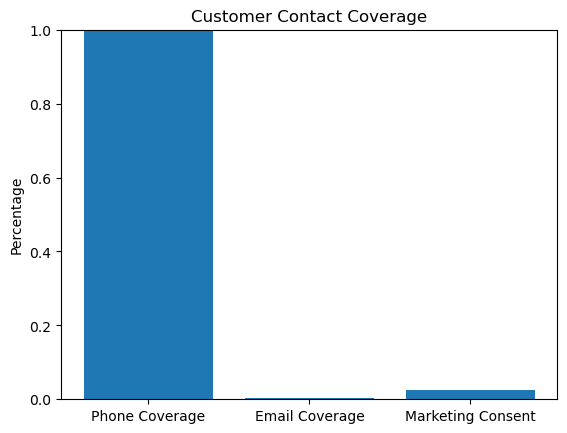

In [97]:
import matplotlib.pyplot as plt

labels = ['Phone Coverage', 'Email Coverage', 'Marketing Consent']
values = [phone_pct, email_pct, marketing_pct]

plt.figure()
plt.bar(labels, values)
plt.title('Customer Contact Coverage')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.show()

## 3.3 Data Quality vs Business Usability

- Objective:
    - Distinguish between data that exists and data that is actually usable for business decisions

- Key Observation:
    - Customer data appears complete at a surface level (e.g., phone numbers captured for all customers)
    - However, key fields required for revenue-driving actions are largely unavailable or unusable

- Data Quality Findings:
    - Phone numbers are consistently captured and can serve as a proxy for customer identity
    - Email addresses are nearly absent, limiting multi-channel engagement
    - Marketing consent is extremely low, restricting the ability to legally contact customers

- Usability Gap:
    - Having customer data does not guarantee it can be used for retention or marketing
    - The dataset lacks the necessary permissions and channels to activate the customer base

- Business Implications:
    - The restaurant is operating with a large but mostly unreachable customer base
    - Repeat business cannot be systematically driven through campaigns or outreach
    - Marketing efforts are likely limited to in-store or passive channels

- Strategic Insight:
    - The constraint is not data collection, but data activation
    - Improving how customer data is captured (especially consent and contact methods) is a high-impact opportunity

- Business Value:
    - Reframes the problem from “missing data” to “underutilized data”
    - Establishes a clear path for improving revenue through better data practices

## 3.4 Attempted Customer Frequency Proxy (Phone-Based)

- Objective:
    - Attempt to approximate customer frequency using phone numbers as a proxy identifier

- Approach:
    - Treat each unique phone number as a customer
    - Count occurrences to estimate repeat interactions

- Assumption:
    - Each phone number corresponds to a unique individual

- Limitations:
    - Phone numbers may be missing, shared, or inconsistently entered
    - Orders dataset does not reliably capture phone numbers
    - This approach provides only a partial and potentially biased view of customer behavior

- Analytical Goal:
    - Evaluate whether meaningful frequency insights can be derived from available data

- Business Value:
    - Tests feasibility of customer-level analysis under current system constraints
    - Helps quantify the impact of missing customer-order linkage

In [98]:
# approximate customer frequency using phone numbers

customer_frequency = (
    customers_final
    .groupby('Phone Number')
    .size()
    .sort_values(ascending=False)
)

print("Top 10 Customer Frequency (Phone-Based Proxy)")
print("-" * 50)

customer_frequency.head(10)

Top 10 Customer Frequency (Phone-Based Proxy)
--------------------------------------------------


Phone Number
120920061462798954439    1
9166621265               1
9166622424               1
9166622198               1
9166622173               1
9166622089               1
9166621857               1
9166621833               1
9166621807               1
9166621541               1
dtype: int64

## 3.5 Frequency Analysis Result & System Limitation

- Objective:
    - Evaluate the effectiveness of using phone numbers as a proxy for customer frequency

- Key Result:
    - All phone numbers appear only once in the dataset
    - No repeat occurrences were detected

- Interpretation:
    - The dataset does not contain transactional records tied to customer identifiers
    - Each row represents a unique customer entry, not a history of orders

- Critical Limitation:
    - Customer frequency cannot be calculated due to lack of linkage between orders and customers
    - The system captures customer data and order data separately, without a connecting key

- Business Implication:
    - The restaurant cannot measure repeat customers, retention, or lifetime value
    - Marketing efforts cannot be optimized based on customer behavior
    - High-value customers cannot be identified or targeted

- Strategic Insight:
    - The limitation is not insufficient data, but insufficient data structure
    - Without customer-order linkage, advanced analytics and revenue optimization are not possible

- Business Value:
    - Clearly demonstrates a structural limitation in the POS system
    - Supports the need for improved data architecture to unlock customer-level insights

## 3.6 Customer Data Quality Segmentation (Phone + Address)

- Objective:
    - Identify customers with the most actionable data based on phone number and address availability

- Approach:
    - Evaluate customer records using:
        - Phone Number (primary identifier)
        - Address Line 1 (location-based signal)

- Rationale:
    - Phone number enables direct outreach (SMS)
    - Address data enables geographic targeting and delivery insights
    - Customers with both fields are the most valuable for marketing and operations

- Business Value:
    - Defines a high-quality customer subset for targeted campaigns
    - Enables more precise marketing strategies (e.g., delivery zones, local promotions)
    - Improves effectiveness of outreach without increasing marketing cost

In [100]:
# create data quality flags
customers_final['has_phone'] = customers_final['Phone Number'].notna()
customers_final['has_address'] = customers_final['Address Line 1'].notna()

# score data completeness (phone + address)
customers_final['data_quality_score'] = (
    customers_final['has_phone'].astype(int) +
    customers_final['has_address'].astype(int)
)

# sort highest quality customers
high_quality_customers = customers_final.sort_values(
    by='data_quality_score', ascending=False
)

high_quality_customers.head(10)

,customer_id_clean,Customer ID,full_name,First Name,Last Name,Phone Number,Email Address,Address Line 1,Customer Since,Marketing Allowed,Marketing Allowed Flag,has_phone,has_address,data_quality_score
0,1,PJ61J5TK1Z6V0,Nan Nan,Nan,Nan,9162129352,NaN,6710 37 Ave,31-Jan-2026 03:18 PM PST,No,0,True,True,2
13076,13077,4VC3210CB2SAP,Clean Foot Nail,Clean,Foot Nail,9164029591,NaN,8190 Florin Rd Nail Salon,27-Mar-2024 12:48 PM PDT,No,0,True,True,2
13053,13054,QNFN58ZMGTRRJ,Nan Nan,Nan,Nan,9162156718,NaN,5125 47 Ave #21,28-Mar-2024 04:42 PM PDT,No,0,True,True,2
13056,13057,A99FKXKDGQT54,Ivan Calderon,Ivan,Calderon,9167434904,NaN,4748 15th Ave,28-Mar-2024 03:30 PM PDT,No,0,True,True,2
13057,13058,V4B84WDBV9S8T,Jimal Nan,Jimal,Nan,9162489588,NaN,8025 Tierra Glen Way,28-Mar-2024 02:52 PM PDT,No,0,True,True,2
13060,13061,K7JX5XEQSBGRP,James Williams,James,Williams,9162085829,NaN,4120 Gaddi Dr Apt3,28-Mar-2024 11:13 AM PDT,No,0,True,True,2
13062,13063,B8MK82Q1GHFTM,"""Lautona,Rake"" Nan","""Lautona,Rake""",Nan,9166640500,NaN,4581 25 Ave,27-Mar-2024 09:23 PM PDT,No,0,True,True,2
13064,13065,J6ZJMSXNBENQY,Marco Nan,Marco,Nan,9168681751,NaN,5226 Thurman Way,27-Mar-2024 08:11 PM PDT,No,0,True,True,2
13066,13067,99C177552N3QJ,Nan Nan,Nan,Nan,9162710226,NaN,2622 San Jose Way,27-Mar-2024 06:55 PM PDT,No,0,True,True,2
13067,13068,A2JTTRNSS9WN4,Nan Nan,Nan,Nan,9165381240,NaN,4124 52 St,27-Mar-2024 05:42 PM PDT,No,0,True,True,2


In [102]:
# count by data quality score
quality_counts = customers_final['data_quality_score'].value_counts().sort_index()

quality_counts

data_quality_score
1    14589
2     9557
Name: count, dtype: int64

In [104]:
print("Customer Data Quality Breakdown:")
print(f"Score 0 (no phone/address): {quality_counts.get(0, 0)}")
print(f"Score 1 (phone only): {quality_counts.get(1, 0)}")
print(f"Score 2 (phone + address): {quality_counts.get(2, 0)}")

Customer Data Quality Breakdown:
Score 0 (no phone/address): 0
Score 1 (phone only): 14589
Score 2 (phone + address): 9557


## 3.7 Campaign Target Dataset (High-Quality Customers)

- Objective:
    - Extract a high-quality subset of customers for SMS campaign testing

- Approach:
    - Filter customers with both phone number and address
    - Deduplicate records to ensure one entry per phone number

- Rationale:
    - This subset represents the most reliable and actionable customer group
    - Reduces noise and improves response quality for campaign testing

- Output:
    - campaign_customers dataset for controlled SMS outreach

In [105]:
# filter high-quality customers (phone + address)
campaign_customers = customers_final[
    customers_final['data_quality_score'] == 2
].copy()

# keep only necessary columns
campaign_customers = campaign_customers[
    [
        'customer_id_clean',
        'Phone Number',
        'Address Line 1'
    ]
]

campaign_customers.head()

,customer_id_clean,Phone Number,Address Line 1
0,1,9162129352,6710 37 Ave
3,4,9162301496,6425 Somis Way
4,5,9163292467,6100 48th Ave #2202
5,6,2792720793,3826 25th Ave
6,7,9162065582,7101 Gerber Rd #216 #8106


In [106]:
campaign_customers = campaign_customers.drop_duplicates(subset='Phone Number')

In [107]:
print("Total campaign customers:", len(campaign_customers))

Total campaign customers: 9557


In [109]:
campaign_customers.to_csv(
    "../data/cleaned/campaign_sms_test_list.csv",
    index=False
)

## 3.8 SMS Campaign Design — Grand Reopening (Test Launch)

- Objective:
    - Launch a controlled SMS campaign to drive traffic for Pizza House’s new location
    - Validate customer contact quality and engagement rates

- Context:
    - Pizza House has relocated, creating a natural opportunity for a "Grand Reopening" campaign
    - Customer dataset lacks strong historical linkage, requiring validation through live engagement

- Target Segment:
    - Customers with:
        - Valid phone numbers
        - Address data available
    - Derived from Section 3.7 (campaign_customers)

- Campaign Strategy:
    - Position message as:
        - Grand Reopening announcement
        - Exclusive VIP-style offer
    - Encourage interaction to validate real customers

- Message Design Principles:
    - Clear identity (Pizza House)
    - Short and direct
    - Action-oriented (reply-based engagement)
    - Incentive-driven

- Test Structure:
    - Initial batch: ~300 customers
    - Measure:
        - Response rate
        - Positive replies (YES)
        - Invalid / noise responses

- Success Criteria:
    - Establish baseline engagement rate
    - Identify verified customer subset
    - Generate immediate revenue from campaign

- Business Value:
    - Converts static customer data into an active marketing channel
    - Creates a validated customer list for future campaigns
    - Demonstrates direct revenue activation from analytics work

### Sample SMS Message (Test Version)

Hey! 🍕 This is Pizza House

We just reopened at our new location 🎉

Want 10% off your next order?

Reply YES and we’ll send your VIP code 👍

##3.9 Campaign Batch Segmentation & Export

- Objective:
    - Split the final SMS campaign dataset into controlled rollout batches for easier execution and performance tracking

- Approach:
    - Randomize the campaign customer list
    - Create separate campaign batches for Day 1, Day 2, and Day 3
    - Further divide Day 1 into A/B groups for message testing

- Rationale:
    - Improves campaign control and reduces execution risk
    - Makes it easier to compare response rates across batches
    - Supports clean follow-up targeting based on campaign performance

- Output:
    - Separate CSV exports for D1_A, D1_B, D2, and D3 campaign lists

In [110]:
# randomize campaign customers for fair batch distribution
campaign_customers = campaign_customers.sample(frac=1, random_state=42).reset_index(drop=True)

# create default batch column
campaign_customers['campaign_batch'] = 'D3'

# assign rollout groups
campaign_customers.loc[campaign_customers.index < 500, 'campaign_batch'] = 'D1_A'
campaign_customers.loc[
    (campaign_customers.index >= 500) & (campaign_customers.index < 1000),
    'campaign_batch'
] = 'D1_B'
campaign_customers.loc[
    (campaign_customers.index >= 1000) & (campaign_customers.index < 4000),
    'campaign_batch'
] = 'D2'

In [111]:
campaign_customers['campaign_batch'].value_counts()

campaign_batch
D3      5557
D2      3000
D1_A     500
D1_B     500
Name: count, dtype: int64

In [112]:
campaign_customers[campaign_customers['campaign_batch'] == 'D1_A'].to_csv(
    "../data/cleaned/campaign_d1_a.csv",
    index=False
)

campaign_customers[campaign_customers['campaign_batch'] == 'D1_B'].to_csv(
    "../data/cleaned/campaign_d1_b.csv",
    index=False
)

campaign_customers[campaign_customers['campaign_batch'] == 'D2'].to_csv(
    "../data/cleaned/campaign_d2.csv",
    index=False
)

campaign_customers[campaign_customers['campaign_batch'] == 'D3'].to_csv(
    "../data/cleaned/campaign_d3.csv",
    index=False
)

# 4.0 Strategic Recommendations — Customer Data & Revenue Activation

- Core Problem:
    - POS system does not reliably link orders to customer records
    - Prevents customer frequency analysis, retention tracking, and LTV modeling

- Strategic Solution:
    - Use SMS engagement as a proxy for customer validation
    - Transform static customer data into an active communication channel

- Customer Activation System:
    - Build an outbound SMS campaign to directly engage customers
    - Capture responses (YES / STOP / No Response) as behavioral signals
    - Convert engagement into a usable customer dataset

- Campaign Execution Optimization:
    - Implement segmented SMS rollout (D1 / D2 / D3 batches) to control risk and improve performance tracking
    - Introduce A/B message testing during initial batch (Day 1) to identify highest-performing messaging
    - Scale campaign based on observed engagement metrics (reply rate, opt-out rate)

- Expected Business Impact:
    - Immediate revenue generation from existing customer base
    - Creation of a verified customer contact list
    - Improved targeting for future promotions and campaigns
    - Foundation for repeatable customer engagement system

## 4.1 Customer Data Strategy

- Problem:
    - POS system does not reliably link orders to customer records
    - Prevents accurate tracking of customer frequency and lifetime value

- Solution:
    - Shift from static customer records to engagement-based validation
    - Use direct communication channels (SMS) to identify active customers

- Engagement-Based Validation Layer:
    - Use SMS campaign responses as a real-world signal to validate active customers
    - Classify customers based on behavior:
        - YES → verified and engaged
        - STOP → invalid or uninterested
        - No Response → unconfirmed

- Expected Outcome:
    - Creation of a usable customer dataset
    - Foundation for future customer-level analysis and targeting

## 4.2 Marketing Strategy

- Objective:
    - Drive immediate engagement and traffic using existing customer data

- Campaign Approach:
    - Launch SMS-based Grand Reopening campaign
    - Offer incentive (10% discount) to encourage response and conversion
    - Use reply-based CTA (YES) to capture engagement

- Controlled Campaign Execution:
    - Deploy SMS campaigns in segmented batches (D1 / D2 / D3) to reduce risk
    - Introduce A/B testing in initial batch (D1_A vs D1_B) to identify optimal messaging
    - Scale campaign based on observed performance metrics

- Expected Outcome:
    - Measurable engagement rates
    - Increased foot traffic and order volume
    - Identification of effective messaging strategies

## 4.3 Revenue Strategy

- Objective:
    - Convert customer engagement into immediate and repeat revenue

- Approach:
    - Use promotional offer to incentivize purchases
    - Target verified customers (YES responders) for highest conversion likelihood

- Performance-Driven Scaling:
    - Allocate future marketing efforts based on observed engagement and conversion rates
    - Prioritize high-response segments for repeat campaigns and upsell opportunities

- Long-Term Strategy:
    - Build a repeatable campaign model to drive ongoing revenue
    - Increase average order value (AOV) through targeted offers and upsells

- Expected Outcome:
    - Immediate revenue lift from campaign
    - Improved efficiency of future marketing spend

## 4.4 Operational Strategy

- Objective:
    - Ensure campaign execution is controlled, measurable, and repeatable

- Execution Plan:
    - Segment customer dataset into controlled rollout batches
    - Monitor campaign performance in real time (replies, opt-outs)
    - Adjust rollout strategy based on early results

- Campaign Feedback Loop:
    - Use real-time SMS response data to continuously refine messaging, targeting, and timing
    - Establish a repeatable system for testing and optimizing customer outreach

- System Integration:
    - Feed campaign results back into customer dataset
    - Maintain updated lists of:
        - Engaged customers
        - Non-responders
        - Opt-outs

- Expected Outcome:
    - Reduced campaign risk
    - Continuous improvement of marketing performance
    - Scalable customer engagement system

## 4.5 Measurement Framework — Campaign Performance & ROI

- Objective:
    - Quantify the effectiveness of the SMS campaign
    - Measure engagement, conversion, and revenue impact
    - Enable data-driven optimization of future campaigns

- Core Metrics:

    - Delivery Rate:
        - % of messages successfully delivered
        - Indicates data quality and phone number validity

    - Reply Rate:
        - % of recipients who respond (YES or STOP)
        - Primary signal of customer engagement

    - YES Rate (Engagement Rate):
        - % of recipients who reply YES
        - Represents verified and active customers

    - Opt-Out Rate (STOP):
        - % of recipients who unsubscribe
        - Measures negative response and list quality

- Conversion Metrics:

    - Redemption Rate:
        - % of YES responders who use the promo code
        - Measures conversion from interest → purchase

    - Revenue per 1,000 Sends:
        - Total campaign revenue / total messages sent × 1,000
        - Standardized performance metric for scalability

- ROI Framework:

    - Campaign Cost:
        - SMS cost per message × total messages sent

    - Campaign Revenue:
        - Total revenue generated from redeemed promo codes

    - Net Profit:
        - Campaign Revenue − Campaign Cost

    - Return on Investment (ROI):
        - (Net Profit / Campaign Cost)

- Performance Benchmarks (Expected Ranges):

    - Reply Rate: ~5% – 15%
    - YES Rate: ~3% – 10%
    - Opt-Out Rate: < 3% – 5%
    - Redemption Rate: ~20% – 40% of YES responders

- Optimization Loop:

    - Compare performance across:
        - Campaign batches (D1, D2, D3)
        - A/B message variants (D1_A vs D1_B)

    - Identify:
        - Highest-performing message
        - Highest-performing segment

    - Apply learnings to:
        - Future campaigns
        - Offer design
        - Send timing and targeting

- Expected Outcome:

    - Clear visibility into campaign effectiveness
    - Ability to scale high-performing strategies
    - Transformation of SMS campaigns into a measurable revenue channel

# 5.0 Executive Summary

- Objective:
    - Activate existing customer data to drive revenue and validate customer contact quality

- Approach:
    - Clean and structure customer dataset from POS exports
    - Filter high-quality customers based on contact information (phone + address)
    - Deploy SMS campaign to engage customers directly

- System Built:
    - Customer data cleaning and deduplication pipeline
    - High-quality campaign dataset (~9,500 contacts)
    - SMS-based customer validation mechanism

- Activation System Upgrade:
    - Introduced a structured SMS campaign system using segmented rollout and A/B testing
    - Enabled controlled experimentation and performance-based scaling
    - Established a repeatable framework for future campaigns

- Key Insight:
    - In the absence of reliable POS linkage, customer engagement must be measured through direct interaction channels

- Business Outcome:
    - Converts dormant customer records into an active revenue channel
    - Establishes a verified audience for future marketing initiatives
    - Demonstrates a scalable, data-driven customer activation system